In [ ]:
%pip install SDV

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.7/204.7 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.6 MB/s eta 0:00:00


In [ ]:
%pip install kaleido==0.2.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 8.2 MB/s eta 0:00:00


In [ ]:
%pip install sdmetrics

In [ ]:
%pip install ydata_profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.0 MB/s eta 0:00:00


In [ ]:
#!pip install -q plotly==6.1.1 kaleido==1.2.0
#!plotly_get_chrome
#!sudo apt update && sudo apt-get install libnss3 libatk-bridge2.0-0 libcups2 libxcomposite1 libxdamage1 libxfixes3 libxrandr2 libgbm1 libxkbcommon0 libpango-1.0-0 libcairo2 libasound2

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np

import pandas as pd
import numpy as np
from sdv.metadata import Metadata
from sdv.single_table import GaussianCopulaSynthesizer

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/FINALFINAL.csv', sep=';', encoding='latin1')
data.head()

,CASEID,FUELTYPE,WEATHER,SURFCOND,VIN,DVTOTAL,ROLLOVER,SPEEDLIMIT,BODYTYPE,PASSENGERS,BELTED_PASSENGERS,GAD1,AIRBAG_DEPLOYED,FIRE
0,2400023,gasoline,clear,dry,1N6AA1ED2MN5,25,no rollover,56,pickup/light truck,2,2,Front,Deployed,missing
1,2400024,gasoline,rain,wet,WDDSJ4EBXGN3,25,no rollover,80,passenger car,2,2,Front,Deployed,missing
2,2400030,gasoline,snow,snow,5FNYF6H03LB0,999,rollover,129,SUV,5,5,Right Side,Deployed,missing
3,2400035,gasoline,clear,dry,5TFCZ5AN5HX1,999,no rollover,89,pickup/light truck,1,1,Front,Deployed,missing
4,2400042,gasoline,rain,wet,1N4AA6AP4GC4,999,no rollover,113,passenger car,1,0,Unknown,Unknown,missing


In [ ]:
data.columns

Index(['CASEID', 'FUELTYPE', 'WEATHER', 'SURFCOND', 'VIN', 'DVTOTAL',
       'ROLLOVER', 'SPEEDLIMIT', 'BODYTYPE', 'PASSENGERS', 'BELTED_PASSENGERS',
       'GAD1', 'AIRBAG_DEPLOYED', 'FIRE'],
      dtype='object')

In [ ]:
data.shape

(736, 14)

In [ ]:
import numpy as np
data['DVTOTAL'] = pd.to_numeric(data['DVTOTAL'], errors='coerce')
data['DVTOTAL'] = data['DVTOTAL'].replace(999, np.nan)
observed_dvtotal = data['DVTOTAL'].dropna()
data.loc[data['DVTOTAL'].isna(), 'DVTOTAL'] = observed_dvtotal.sample(data['DVTOTAL'].isna().sum(), replace=True).values

data['SPEEDLIMIT'] = pd.to_numeric(data['SPEEDLIMIT'], errors='coerce')
data['SPEEDLIMIT'] = data['SPEEDLIMIT'].replace(999, np.nan)
observed_speedlimit = data['SPEEDLIMIT'].dropna()
data.loc[data['SPEEDLIMIT'].isna(), 'SPEEDLIMIT'] = observed_speedlimit.sample(data['SPEEDLIMIT'].isna().sum(), replace=True).values

categorical_columns = [
    'FUELTYPE', 'WEATHER', 'SURFCOND', 'ROLLOVER',
    'BODYTYPE', 'GAD1', 'AIRBAG_DEPLOYED', 'FIRE'
]
for col in categorical_columns:
    data[col] = data[col].astype(str).str.strip()
    data[col] = data[col].replace({'nan': 'Unknown', 'NaN': 'Unknown', '': 'Unknown'})


In [ ]:
data = data.drop(columns=['CASEID'])
data.head()

,FUELTYPE,WEATHER,SURFCOND,VIN,DVTOTAL,ROLLOVER,SPEEDLIMIT,BODYTYPE,PASSENGERS,BELTED_PASSENGERS,GAD1,AIRBAG_DEPLOYED,FIRE
0,gasoline,clear,dry,1N6AA1ED2MN5,25.0,no rollover,56.0,pickup/light truck,2,2,Front,Deployed,missing
1,gasoline,rain,wet,WDDSJ4EBXGN3,25.0,no rollover,80.0,passenger car,2,2,Front,Deployed,missing
2,gasoline,snow,snow,5FNYF6H03LB0,13.0,rollover,129.0,SUV,5,5,Right Side,Deployed,missing
3,gasoline,clear,dry,5TFCZ5AN5HX1,14.0,no rollover,89.0,pickup/light truck,1,1,Front,Deployed,missing
4,gasoline,rain,wet,1N4AA6AP4GC4,21.0,no rollover,113.0,passenger car,1,0,Unknown,Unknown,missing


In [ ]:
metadata = Metadata.detect_from_dataframe(data=data)
metadata.update_column(column_name='FUELTYPE', table_name='table', sdtype='categorical')
metadata.update_column(column_name='WEATHER', table_name='table', sdtype='categorical')
metadata.update_column(column_name='SURFCOND', table_name='table', sdtype='categorical')
metadata.update_column(column_name='DVTOTAL', table_name='table', sdtype='numerical')
metadata.update_column(column_name='ROLLOVER', table_name='table', sdtype='categorical')
metadata.update_column(column_name='SPEEDLIMIT', table_name='table', sdtype='numerical')
metadata.update_column(column_name='BODYTYPE', table_name='table', sdtype='categorical')
metadata.update_column(column_name='PASSENGERS', table_name='table', sdtype='numerical')
metadata.update_column(column_name='BELTED_PASSENGERS', table_name='table', sdtype='numerical')
metadata.update_column(column_name='GAD1', table_name='table', sdtype='categorical')
metadata.update_column(column_name='AIRBAG_DEPLOYED', table_name='table', sdtype='categorical')
metadata.update_column(column_name='FIRE', table_name='table', sdtype='categorical')
metadata

{
    "tables": {
        "table": {
            "columns": {
                "FUELTYPE": {
                    "sdtype": "categorical"
                },
                "WEATHER": {
                    "sdtype": "categorical"
                },
                "SURFCOND": {
                    "sdtype": "categorical"
                },
                "VIN": {
                    "pii": true,
                    "sdtype": "vin"
                },
                "DVTOTAL": {
                    "sdtype": "numerical"
                },
                "ROLLOVER": {
                    "sdtype": "categorical"
                },
                "SPEEDLIMIT": {
                    "sdtype": "numerical"
                },
                "BODYTYPE": {
                    "sdtype": "categorical"
                },
                "PASSENGERS": {
                    "sdtype": "numerical"
                },
                "BELTED_PASSENGERS": {
                    "sdtype": "numerical"
    

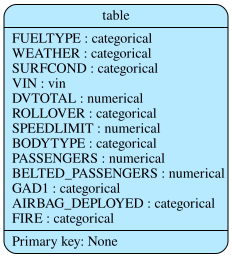

In [ ]:
metadata.visualize()

In [ ]:
synthesizer = GaussianCopulaSynthesizer(
    metadata,
    enforce_min_max_values=True,
    enforce_rounding=True,
    default_distribution='beta',
    numerical_distributions={
        'DVTOTAL': 'gaussian_kde',
        'SPEEDLIMIT': 'gaussian_kde'
    }
)


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


In [ ]:
import numpy as np
import pandas as pd

# ─── Budget ───────────────────────────────────────────
TOTAL_EPSILON = 3.0
DELTA         = 1e-5
EPSILON_NUM   = 1.0
EPSILON_CAT   = (TOTAL_EPSILON - EPSILON_NUM) / 8

print(f"DP-budget: ε_total={TOTAL_EPSILON}, δ={DELTA}")
print(f"  Numeriska (DVTOTAL, SPEEDLIMIT, PASSENGERS, BELTED): ε={EPSILON_NUM}")
print(f"  Kategoriska (8 kolumner): ε={EPSILON_CAT:.3f} × 8 = {EPSILON_CAT*8:.1f}")

synthesizer = GaussianCopulaSynthesizer(
    metadata,
    enforce_min_max_values=True,
    enforce_rounding=True,
    default_distribution='beta',
    numerical_distributions={
        'DVTOTAL': 'gaussian_kde',
        'SPEEDLIMIT': 'gaussian_kde'
    }
)
synthesizer.fit(data)
synthetic_data = synthesizer.sample(num_rows=len(data))

sigma = np.sqrt(2 * np.log(1.25 / DELTA)) / EPSILON_NUM

def dp_gaussian(series, sensitivity, sigma):
    noise = np.random.normal(0, sensitivity * sigma, size=len(series))
    return series + noise

synthetic_data['DVTOTAL'] = dp_gaussian(
    synthetic_data['DVTOTAL'].fillna(0),
    float(data['DVTOTAL'].std()), sigma
).clip(0, 999).round()

synthetic_data['SPEEDLIMIT'] = dp_gaussian(
    synthetic_data['SPEEDLIMIT'].fillna(0),
    float(data['SPEEDLIMIT'].std()), sigma
).clip(0, 130).round()

synthetic_data['PASSENGERS'] = dp_gaussian(
    synthetic_data['PASSENGERS'].fillna(0),
    float(data['PASSENGERS'].std()), sigma
).clip(0, data['PASSENGERS'].max()).round()

synthetic_data['BELTED_PASSENGERS'] = dp_gaussian(
    synthetic_data['BELTED_PASSENGERS'].fillna(0),
    float(data['BELTED_PASSENGERS'].std()), sigma
).clip(0, data['BELTED_PASSENGERS'].max()).round()


p = synthetic_data['PASSENGERS']
b = synthetic_data['BELTED_PASSENGERS']
synthetic_data['BELTED_PASSENGERS'] = b.where(b <= p, other=p)


def dp_categorical(series, epsilon):
    valid_cats = data[series.name].dropna().unique()  # bara kategorier från riktiga datan
    counts = series.value_counts().reindex(valid_cats, fill_value=0)
    noisy_counts = counts + np.random.laplace(0, 1.0 / epsilon, size=len(counts))
    noisy_counts = noisy_counts.clip(0)
    probs = noisy_counts / noisy_counts.sum()
    return np.random.choice(probs.index, size=len(series), p=probs.values)

categorical_dp_cols = [
    'FUELTYPE', 'WEATHER', 'SURFCOND', 'ROLLOVER',
    'BODYTYPE', 'GAD1', 'AIRBAG_DEPLOYED', 'FIRE'
]

for col in categorical_dp_cols:
    synthetic_data[col] = dp_categorical(synthetic_data[col], epsilon=EPSILON_CAT)

print(f"\nDP applicerat på alla kolumner.")
print(f"Violations BELTED > PASSENGERS: {(synthetic_data['BELTED_PASSENGERS'] > synthetic_data['PASSENGERS']).sum()}")

for col in ['DVTOTAL', 'SPEEDLIMIT', 'PASSENGERS']:
    real_min = data[col].min()
    real_max = data[col].max()
    synthetic_data[col] = synthetic_data[col].clip(real_min, real_max)

synthetic_data['PASSENGERS'] = synthetic_data['PASSENGERS'].astype('int64')
synthetic_data['BELTED_PASSENGERS'] = synthetic_data['BELTED_PASSENGERS'].astype('int64')

DP-budget: ε_total=3.0, δ=1e-05
  Numeriska (DVTOTAL, SPEEDLIMIT, PASSENGERS, BELTED): ε=1.0
  Kategoriska (8 kolumner): ε=0.250 × 8 = 2.0

DP applicerat på alla kolumner.
Violations BELTED > PASSENGERS: 0


In [ ]:
columns = [
    'FUELTYPE',
    'WEATHER',
    'SURFCOND',
    'VIN',
    'DVTOTAL',
    'ROLLOVER',
    'SPEEDLIMIT',
    'BODYTYPE',
    'PASSENGERS',
    'BELTED_PASSENGERS',
    'GAD1',
    'AIRBAG_DEPLOYED',
    'FIRE'
]

for col in columns:
    print(f'\n--- {col} ---')
    display(
        pd.DataFrame({
            'Real': data[col].value_counts(),
            'Synthetic': synthetic_data[col].value_counts()
        }).fillna(0)
    )


--- FUELTYPE ---


,Real,Synthetic
FUELTYPE,,
diesel,15,21
gasoline,693,697
gasoline/ethanol,21,13
gasoline/lithium (elbil),7,5



--- WEATHER ---


,Real,Synthetic
WEATHER,,
clear,564,577
rain,68,68
cloudy,64,67
snow,20,15
unknown,20,9



--- SURFCOND ---


...

,Real,Synthetic
GAD1,,
Back/Truck Back,8,8
Front,573,591
Left Side,36,33
Noncollision,6,5
Right Side,37,25
Top,53,51
Undercarriage,11,18
Unknown,12,5



--- AIRBAG_DEPLOYED ---


,Real,Synthetic
AIRBAG_DEPLOYED,,
Deployed,375,387
Not deployed/not available,254,267
Unknown,107,82



--- FIRE ---


,Real,Synthetic
FIRE,,
fire,2,0.0
missing,731,730.0
no fire,3,6.0


In [ ]:
synthetic_data.to_csv('/content/drive/MyDrive/Colab Notebooks/synthetic_FINALA_GAUSSIAN.csv', index=False, sep=';')

In [ ]:
from sdv.evaluation.single_table import run_diagnostic, evaluate_quality

In [ ]:
diagnostic = run_diagnostic(
    real_data=data,
    synthetic_data=synthetic_data,
    metadata=metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 13/13 [00:00<00:00, 254.34it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 56.87it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%



In [ ]:
diagnostic.get_score()

np.float64(1.0)

In [ ]:
quality_report = evaluate_quality(
    real_data=data,
    synthetic_data=synthetic_data,
    metadata=metadata
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 13/13 [00:00<00:00, 188.74it/s]|
Column Shapes Score: 86.57%

(2/2) Evaluating Column Pair Trends: |██████████| 78/78 [00:00<00:00, 81.21it/s]| 
Column Pair Trends Score: 95.15%

Overall Score (Average): 90.86%



In [ ]:
quality_report.get_score()

np.float64(0.9086099784348327)

In [ ]:
diagnostic.get_details(property_name='Data Validity')

,Column,Metric,Score
0,FUELTYPE,CategoryAdherence,1.0
1,WEATHER,CategoryAdherence,1.0
2,SURFCOND,CategoryAdherence,1.0
3,DVTOTAL,BoundaryAdherence,1.0
4,ROLLOVER,CategoryAdherence,1.0
5,SPEEDLIMIT,BoundaryAdherence,1.0
6,BODYTYPE,CategoryAdherence,1.0
7,PASSENGERS,BoundaryAdherence,1.0
8,BELTED_PASSENGERS,BoundaryAdherence,1.0
9,GAD1,CategoryAdherence,1.0


In [ ]:
quality_report.get_details(property_name='Column Shapes')

,Column,Metric,Score
0,FUELTYPE,TVComplement,0.986413
1,WEATHER,TVComplement,0.978261
2,SURFCOND,TVComplement,0.947011
3,DVTOTAL,KSComplement,0.684783
4,ROLLOVER,TVComplement,0.966033
5,SPEEDLIMIT,KSComplement,0.573370
6,BODYTYPE,TVComplement,0.927989
7,PASSENGERS,KSComplement,0.773098
8,BELTED_PASSENGERS,KSComplement,0.623641
9,GAD1,TVComplement,0.966033


In [ ]:
quality_report.get_details(property_name='Column Pair Trends')

,Column 1,Column 2,Metric,Score,Real Correlation,Synthetic Correlation,Real Association,Meets Threshold?
0,FUELTYPE,WEATHER,ContingencySimilarity,NaN,NaN,NaN,0.106304,False
1,FUELTYPE,SURFCOND,ContingencySimilarity,NaN,NaN,NaN,0.125589,False
2,FUELTYPE,DVTOTAL,ContingencySimilarity,NaN,NaN,NaN,0.104183,False
3,FUELTYPE,ROLLOVER,ContingencySimilarity,NaN,NaN,NaN,0.052934,False
4,FUELTYPE,SPEEDLIMIT,ContingencySimilarity,NaN,NaN,NaN,0.117164,False
...,...,...,...,...,...,...,...,...
61,BELTED_PASSENGERS,AIRBAG_DEPLOYED,ContingencySimilarity,NaN,NaN,NaN,0.275610,False
62,BELTED_PASSENGERS,FIRE,ContingencySimilarity,NaN,NaN,NaN,0.035446,False
63,GAD1,AIRBAG_DEPLOYED,ContingencySimilarity,NaN,NaN,NaN,0.256907,False
64,GAD1,FIRE,ContingencySimilarity,NaN,NaN,NaN,0.176186,False


In [ ]:
from sdmetrics.reports.single_table import QualityReport, DiagnosticReport
from sdmetrics.single_table import MulticlassDecisionTreeClassifier

meta_dict = metadata.to_dict()
inner_meta = meta_dict['tables'][list(meta_dict['tables'].keys())[0]] if 'tables' in meta_dict else meta_dict

cols_to_drop = [
    col for col, info in inner_meta['columns'].items()
    if info.get('sdtype') in ['id', 'vin']
]

data_eval = data.drop(columns=cols_to_drop, errors='ignore').copy()
syn_eval = synthetic_data.drop(columns=cols_to_drop, errors='ignore').copy()

eval_meta = {
    'columns': {
        k: v for k, v in inner_meta['columns'].items()
        if k not in cols_to_drop
    }
}

data_for_utility = data_eval.copy()
syn_for_utility = syn_eval.copy()

categorical_cols = data_for_utility.select_dtypes(include=['object', 'category', 'bool']).columns

for col in categorical_cols:
    common_categories = set(data_for_utility[col].dropna().unique()) & set(syn_for_utility[col].dropna().unique())
    data_for_utility = data_for_utility[data_for_utility[col].isin(common_categories) | data_for_utility[col].isna()]
    syn_for_utility = syn_for_utility[syn_for_utility[col].isin(common_categories) | syn_for_utility[col].isna()]

q_report = QualityReport()
q_report.generate(data_eval, syn_eval, eval_meta)

d_report = DiagnosticReport()
d_report.generate(data_eval, syn_eval, eval_meta)

targets = [
    'AIRBAG_DEPLOYED',
    'ROLLOVER',
    'BODYTYPE',
    'WEATHER',
    'SURFCOND',
    'GAD1'
]

utility_scores = {}

for target in targets:
    data_tmp = data_eval.copy()
    syn_tmp = syn_eval.copy()

    categorical_cols = data_tmp.select_dtypes(include=['object', 'category', 'bool']).columns

    for col in categorical_cols:
        common_categories = set(data_tmp[col].dropna().unique()) & set(syn_tmp[col].dropna().unique())
        data_tmp = data_tmp[data_tmp[col].isin(common_categories) | data_tmp[col].isna()]
        syn_tmp = syn_tmp[syn_tmp[col].isin(common_categories) | syn_tmp[col].isna()]

    try:
        score = MulticlassDecisionTreeClassifier.compute(
            test_data=data_tmp,
            train_data=syn_tmp,
            target=target,
            metadata=eval_meta
        )
        utility_scores[target] = score
    except Exception as e:
        utility_scores[target] = None
        print(f'Utility-fel för {target}: {e}')

valid_scores = [score for score in utility_scores.values() if score is not None]
average_utility = sum(valid_scores) / len(valid_scores) if valid_scores else 0.0

print('\n' + '=' * 40)
print('SYNTHETIC DATA SCORECARD')
print('=' * 40)
print(f'Quality Score: {q_report.get_score() * 100:.2f}%')
print(f'Diagnostic Score: {d_report.get_score() * 100:.2f}%')
print('-' * 40)
print('Utility Scores by Target:')

for target in targets:
    score = utility_scores[target]
    if score is not None:
        print(f'{target}: {score * 100:.2f}%')
    else:
        print(f'{target}: Failed')

print('-' * 40)
print(f'Average Utility Score: {average_utility * 100:.2f}%')
print('=' * 40)
print(f'Utility rows used: {len(data_for_utility)}')

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 235.01it/s]|
Column Shapes Score: 86.57%

(2/2) Evaluating Column Pair Trends: |██████████| 66/66 [00:01<00:00, 55.94it/s]|
Column Pair Trends Score: 95.15%

Overall Score (Average): 90.86%

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 12/12 [00:00<00:00, 390.08it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 103.37it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%


SYNTHETIC DATA SCORECARD
Quality Score: 90.86%
Diagnostic Score: 100.00%
----------------------------------------
Utility Scores by Target:
AIRBAG_DEPLOYED: 36.12%
ROLLOVER: 35.78%
BODYTYPE: 26.18%
WEATHER: 18.95%
SURFCOND: 18.74%
GAD1: 11.37%
----------------------------------------
Average Utility Score: 24.52%
Utility rows used: 727


In [ ]:
from sdmetrics.single_table import DCRBaselineProtection

# Konvertera metadata om det behövs
meta_dict = metadata.to_dict()
if 'tables' in meta_dict:
    table_name = list(meta_dict['tables'].keys())[0]
    metadata_for_metric = meta_dict['tables'][table_name]
else:
    metadata_for_metric = meta_dict

# 1. Beräkna enligt din dokumentationsbeskrivning
score_breakdown = DCRBaselineProtection.compute_breakdown(
    real_data=data,
    synthetic_data=synthetic_data,
    metadata=metadata_for_metric
)

# 2. Hämta värdena från ordboken
total_score = score_breakdown['score']
median_dcr_synthetic = score_breakdown['median_DCR_to_real_data']['synthetic_data']
median_dcr_baseline = score_breakdown['median_DCR_to_real_data']['random_data_baseline']

print(f"Integritetspoäng (Score): {total_score}")
print(f"Median-DCR för syntetisk data: {median_dcr_synthetic}")
print(f"Median-DCR för slumpmässig baslinje: {median_dcr_baseline}")

Integritetspoäng (Score): 0.25396699518689414
Median-DCR för syntetisk data: 0.09434865900383141
Median-DCR för slumpmässig baslinje: 0.3714996861478016


In [ ]:
from ydata_profiling import ProfileReport


real_profile = ProfileReport(data, title="Real Data Profile", explorative=True)

synth_profile = ProfileReport(synthetic_data, title="Synthetic Data Profile", explorative=True)

validation_report = real_profile.compare(synth_profile)

validation_report.to_notebook_iframe()

validation_report.to_file("synthetic_data_validation.html")

/tmp/ipykernel_14904/3184684242.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:00<00:00, 45.04it/s]


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:00<00:00, 46.35it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
from sdv.evaluation.single_table import get_column_plot

In [ ]:
save_path = "/content/drive/MyDrive/Colab Notebooks/results/plots_GAUSSIAN"

In [ ]:
import pandas as pd
import numpy as np

real = data.copy()
syn = synthetic_data.copy()

categorical_cols = [
    'FUELTYPE',
    'WEATHER',
    'SURFCOND',
    'ROLLOVER',
    'BODYTYPE',
    'PASSENGERS',
    'BELTED_PASSENGERS',
    'GAD1',
    'AIRBAG_DEPLOYED',
    'FIRE'
]

numerical_cols = [
    'DVTOTAL',
    'SPEEDLIMIT'
]

all_cols = categorical_cols + numerical_cols

real = real[all_cols].copy()
syn = syn[all_cols].copy()

for col in categorical_cols:
    real[col] = real[col].astype(str)
    syn[col] = syn[col].astype(str)

for col in numerical_cols:
    real[col] = pd.to_numeric(real[col], errors='coerce')
    syn[col] = pd.to_numeric(syn[col], errors='coerce')

In [ ]:
from scipy.stats import wasserstein_distance

wasserstein_results = []

for col in numerical_cols:
    r = real[col].dropna()
    s = syn[col].dropna()
    score = wasserstein_distance(r, s)
    wasserstein_results.append({
        "Variable": col,
        "Wasserstein Distance": score
    })

wasserstein_df = pd.DataFrame(wasserstein_results)
wasserstein_df

,Variable,Wasserstein Distance
0,DVTOTAL,21.048913
1,SPEEDLIMIT,21.500000


In [ ]:
from scipy.spatial.distance import jensenshannon

js_results = []

for col in categorical_cols:
    real_counts = real[col].value_counts(normalize=True)
    syn_counts = syn[col].value_counts(normalize=True)
    categories = sorted(set(real_counts.index).union(set(syn_counts.index)))

    p = real_counts.reindex(categories, fill_value=0).values
    q = syn_counts.reindex(categories, fill_value=0).values

    score = jensenshannon(p, q) ** 2

    js_results.append({
        "Variable": col,
        "Jensen-Shannon Divergence": score
    })

js_df = pd.DataFrame(js_results)
js_df


,Variable,Jensen-Shannon Divergence
0,FUELTYPE,0.001104
1,WEATHER,0.001770
2,SURFCOND,0.003207
3,ROLLOVER,0.000887
4,BODYTYPE,0.005795
5,PASSENGERS,0.059889
6,BELTED_PASSENGERS,0.110931
7,GAD1,0.002565
8,AIRBAG_DEPLOYED,0.001301
9,FIRE,0.001288


In [ ]:
encoded_real = pd.get_dummies(real, columns=categorical_cols, dummy_na=False)
encoded_syn = pd.get_dummies(syn, columns=categorical_cols, dummy_na=False)

encoded_real, encoded_syn = encoded_real.align(encoded_syn, join='outer', axis=1, fill_value=0)

real_corr = encoded_real.corr().fillna(0)
syn_corr = encoded_syn.corr().fillna(0)

corr_diff = np.abs(real_corr - syn_corr)

mean_corr_difference = corr_diff.values.mean()

mean_corr_difference

np.float64(0.04397491712783816)

In [ ]:
from sklearn.metrics import mutual_info_score

mi_results = []

for col1 in all_cols:
    for col2 in all_cols:
        if col1 < col2:
            r1 = real[col1].astype(str)
            r2 = real[col2].astype(str)
            s1 = syn[col1].astype(str)
            s2 = syn[col2].astype(str)

            real_mi = mutual_info_score(r1, r2)
            syn_mi = mutual_info_score(s1, s2)

            mi_results.append({
                "Variable 1": col1,
                "Variable 2": col2,
                "Real MI": real_mi,
                "Synthetic MI": syn_mi,
                "Absolute Difference": abs(real_mi - syn_mi)
            })

mi_df = pd.DataFrame(mi_results)
mi_df.sort_values("Absolute Difference", ascending=False).head(15)

,Variable 1,Variable 2,Real MI,Synthetic MI,Absolute Difference
63,DVTOTAL,SPEEDLIMIT,0.353000,0.772559,0.419559
22,PASSENGERS,SPEEDLIMIT,0.039758,0.240450,0.200693
32,BELTED_PASSENGERS,SPEEDLIMIT,0.049203,0.181858,0.132655
18,BODYTYPE,SPEEDLIMIT,0.059721,0.178112,0.118392
28,BELTED_PASSENGERS,PASSENGERS,0.367095,0.249497,0.117597
64,SPEEDLIMIT,WEATHER,0.043119,0.159059,0.115939
65,SPEEDLIMIT,SURFCOND,0.076220,0.187654,0.111434
48,AIRBAG_DEPLOYED,SPEEDLIMIT,0.023695,0.130093,0.106398
60,DVTOTAL,PASSENGERS,0.122486,0.224066,0.101580
37,GAD1,SPEEDLIMIT,0.070979,0.157207,0.086228


In [ ]:
constraint_results = {}

if "PASSENGERS" in real.columns and "BELTED_PASSENGERS" in real.columns:
    real_pass = pd.to_numeric(real["PASSENGERS"], errors="coerce")
    real_belt = pd.to_numeric(real["BELTED_PASSENGERS"], errors="coerce")
    syn_pass = pd.to_numeric(syn["PASSENGERS"], errors="coerce")
    syn_belt = pd.to_numeric(syn["BELTED_PASSENGERS"], errors="coerce")

    real_valid = (real_belt <= real_pass).mean()
    syn_valid = (syn_belt <= syn_pass).mean()

    constraint_results["BELTED_PASSENGERS <= PASSENGERS"] = {
        "Real Validity": real_valid,
        "Synthetic Validity": syn_valid
    }

for col in ["DVTOTAL", "SPEEDLIMIT"]:
    if col in real.columns:
        real_valid = (pd.to_numeric(real[col], errors="coerce") >= 0).mean()
        syn_valid = (pd.to_numeric(syn[col], errors="coerce") >= 0).mean()

        constraint_results[f"{col} >= 0"] = {
            "Real Validity": real_valid,
            "Synthetic Validity": syn_valid
        }

constraint_df = pd.DataFrame(constraint_results).T
constraint_df

,Real Validity,Synthetic Validity
BELTED_PASSENGERS <= PASSENGERS,1.0,1.0
DVTOTAL >= 0,1.0,1.0
SPEEDLIMIT >= 0,1.0,1.0


In [ ]:
real_rows = real.astype(str).apply(lambda row: "|".join(row.values), axis=1)
syn_rows = syn.astype(str).apply(lambda row: "|".join(row.values), axis=1)

duplicate_rate = syn_rows.isin(real_rows).mean()

duplicate_rate

np.float64(0.0)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

categorical_cols = data.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = data.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

preprocessor_ml = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ],
    remainder="drop"
)
real_model = Pipeline(steps=[
    ("preprocessor", preprocessor_ml),
    ("classifier", RandomForestClassifier(random_state=42))
])

synthetic_model = Pipeline(steps=[
    ("preprocessor", preprocessor_ml),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [ ]:
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Sätt real och syn
real = data.copy()
syn = synthetic_data.copy()

# Definiera all_cols från faktisk data (undviker VIN och saknade kolumner)
all_cols = [col for col in real.columns if col in syn.columns]

target = "AIRBAG_DEPLOYED"
features = [col for col in all_cols if col != target]

# Preprocessor
categorical_cols = real[features].select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = real[features].select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

preprocessor_ml = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ],
    remainder="drop"
)

# Förbered data
real_ml = real[features + [target]].dropna().copy()
syn_ml = syn[features + [target]].dropna().copy()

X_real = real_ml[features]
y_real = real_ml[target].astype(str)

X_syn = syn_ml[features]
y_syn = syn_ml[target].astype(str)

X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_real,
    y_real,
    test_size=0.3,
    random_state=42,
    stratify=y_real
)

# Modeller
real_model = Pipeline([
    ("preprocessor", clone(preprocessor_ml)),
    ("classifier", RandomForestClassifier(random_state=42))
])

synthetic_model = Pipeline([
    ("preprocessor", clone(preprocessor_ml)),
    ("classifier", RandomForestClassifier(random_state=42))
])

# Träna
real_model.fit(X_train_real, y_train_real)
synthetic_model.fit(X_syn, y_syn)

# Predicera
real_pred = real_model.predict(X_test_real)
synthetic_pred = synthetic_model.predict(X_test_real)

# Resultat
ml_utility_results = pd.DataFrame([
    {
        "Training Data": "Real",
        "Test Data": "Real",
        "Accuracy": accuracy_score(y_test_real, real_pred),
        "F1 Macro": f1_score(y_test_real, real_pred, average="macro")
    },
    {
        "Training Data": "Synthetic",
        "Test Data": "Real",
        "Accuracy": accuracy_score(y_test_real, synthetic_pred),
        "F1 Macro": f1_score(y_test_real, synthetic_pred, average="macro")
    }
])

ml_utility_results

,Training Data,Test Data,Accuracy,F1 Macro
0,Real,Real,0.493213,0.358880
1,Synthetic,Real,0.520362,0.271127


In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Förbered numerisk representation av datan
nn_features = [col for col in real.columns if col in syn.columns and col != target]

cat_cols_nn = real[nn_features].select_dtypes(include=["object", "category"]).columns.tolist()
num_cols_nn = real[nn_features].select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

nn_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols_nn),
        ("num", "passthrough", num_cols_nn)
    ],
    remainder="drop"
)

real_nn = real[nn_features].dropna().copy()
syn_nn = syn[nn_features].dropna().copy()

# Anpassa på riktig data och transformera båda
real_transformed = nn_preprocessor.fit_transform(real_nn)
syn_transformed = nn_preprocessor.transform(syn_nn)

# Beräkna närmaste granne från syntetisk → riktig data
nn = NearestNeighbors(n_neighbors=1, metric="euclidean")
nn.fit(real_transformed)
distances, _ = nn.kneighbors(syn_transformed)

nearest_neighbor_mean = distances.mean()
print(f"Nearest Neighbor Mean Distance: {nearest_neighbor_mean:.4f}")

Nearest Neighbor Mean Distance: 9.5119


In [ ]:
summary_metrics = pd.DataFrame([
    {
        "Metric": "Mean Wasserstein Distance",
        "Value": wasserstein_df["Wasserstein Distance"].mean(),
        "Interpretation": "Lower is better"
    },
    {
        "Metric": "Mean Jensen-Shannon Divergence",
        "Value": js_df["Jensen-Shannon Divergence"].mean(),
        "Interpretation": "Lower is better"
    },
    {
        "Metric": "Mean Correlation Difference",
        "Value": mean_corr_difference,
        "Interpretation": "Lower is better"
    },
    {
        "Metric": "Mean Mutual Information Difference",
        "Value": mi_df["Absolute Difference"].mean(),
        "Interpretation": "Lower is better"
    },
    {
        "Metric": "Duplicate Rate",
        "Value": duplicate_rate,
        "Interpretation": "Lower is better"
    },
    {
        "Metric": "Nearest Neighbor Mean Distance",
        "Value": nearest_neighbor_mean,
        "Interpretation": "Higher may indicate less memorization"
    }
])

summary_metrics

,Metric,Value,Interpretation
0,Mean Wasserstein Distance,21.274457,Lower is better
1,Mean Jensen-Shannon Divergence,0.018874,Lower is better
2,Mean Correlation Difference,0.043975,Lower is better
3,Mean Mutual Information Difference,0.033624,Lower is better
4,Duplicate Rate,0.000000,Lower is better
5,Nearest Neighbor Mean Distance,9.511895,Higher may indicate less memorization


In [ ]:
from sdv.evaluation.single_table import get_column_plot
import matplotlib.pyplot as plt
import os
save_path = '/content/drive/MyDrive/Colab Notebooks/bilder'

if not os.path.exists(save_path):
    os.makedirs(save_path)

columns = [
    'FUELTYPE',
    'WEATHER',
    'SURFCOND',
    'DVTOTAL',
    'ROLLOVER',
    'SPEEDLIMIT',
    'BODYTYPE',
    'PASSENGERS',
    'BELTED_PASSENGERS',
    'GAD1',
    'AIRBAG_DEPLOYED',
    'FIRE'
]

for col in columns:
    fig = get_column_plot(
        real_data=data,
        synthetic_data=synthetic_data,
        column_name=col,
        metadata=metadata
    )

    img_bytes = fig.to_image(format="png", scale=2)

    with open(f"{save_path}/{col}.png", "wb") as f:
        f.write(img_bytes)

    fig.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

categorical_columns = [
    'FUELTYPE',
    'WEATHER',
    'SURFCOND',
    'ROLLOVER',
    'BODYTYPE',
    'GAD1',
    'AIRBAG_DEPLOYED',
    'FIRE'
]

numerical_columns = [
    'DVTOTAL',
    'SPEEDLIMIT',
    'PASSENGERS',
    'BELTED_PASSENGERS'
]

for col in categorical_columns:
    counts_df = pd.DataFrame({
        'Real': data[col].value_counts(),
        'Synthetic': synthetic_data[col].value_counts()
    }).fillna(0)

    counts_df.plot(kind='bar', figsize=(8,5))
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.title(f'Real vs Synthetic: {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

for col in numerical_columns:
    plt.figure(figsize=(8,5))
    plt.hist(pd.to_numeric(data[col], errors='coerce').dropna(), alpha=0.5, label='Real')
    plt.hist(pd.to_numeric(synthetic_data[col], errors='coerce').dropna(), alpha=0.5, label='Synthetic')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.title(f'Real vs Synthetic: {col}')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
from sdv.evaluation.single_table import get_column_pair_plot
import os

save_path = "/content/drive/MyDrive/Colab Notebooks/results/plots_GAUSSIAN_compare"
os.makedirs(save_path, exist_ok=True)

pairs = [
    ['DVTOTAL', 'AIRBAG_DEPLOYED'],
    ['DVTOTAL', 'ROLLOVER'],
    ['PASSENGERS', 'BELTED_PASSENGERS'],
    ['WEATHER', 'SURFCOND'],
    ['SPEEDLIMIT', 'DVTOTAL'],
    ['BODYTYPE', 'ROLLOVER'],
    ['SURFCOND', 'ROLLOVER'],
    ['DVTOTAL', 'FIRE']
]

for pair in pairs:
    fig = get_column_pair_plot(
        real_data=data,
        synthetic_data=synthetic_data,
        column_names=pair,
        metadata=metadata
    )

    fig.update_layout(
        title=f"Real vs Synthetic: {pair[0]} vs {pair[1]}",
        title_x=0.5,
        width=950,
        height=600,
        template='plotly_white'
    )

    filename = f"{pair[0]}_{pair[1]}.png"

    img_bytes = fig.to_image(format="png")

    with open(f"{save_path}/{filename}", "wb") as f:
        f.write(img_bytes)

    fig.show()

In [ ]:
import numpy as np
import pandas as pd

synthetic_data["DVTOTAL"] = pd.to_numeric(synthetic_data["DVTOTAL"], errors="coerce").replace(999, np.nan)
synthetic_data["SPEEDLIMIT"] = pd.to_numeric(synthetic_data["SPEEDLIMIT"], errors="coerce").replace(999, np.nan)

In [ ]:
import json
import pandas as pd
import numpy as np

synthetic_data["DVTOTAL"] = pd.to_numeric(synthetic_data["DVTOTAL"], errors="coerce").replace(999, np.nan)
synthetic_data["SPEEDLIMIT"] = pd.to_numeric(synthetic_data["SPEEDLIMIT"], errors="coerce").replace(999, np.nan)

weather_map = {
    0: "Missing",
    1: "Clear",
    2: "Rain",
    3: "Sleet/Hail",
    4: "Snow",
    5: "Smoke/Fog",
    6: "Strong crosswind",
    8: "Cloudy",
    9: "Blowing snow",
    10: "Freezing rain"
}

rollover_map = {
    0: "Unknown",
    1: "No rollover",
    2: "Rollover"
}

surfcond_map = {
    0: "Missing",
    1: "Dry",
    2: "Wet",
    3: "Snow",
    4: "Slush",
    5: "Ice/Frost",
    6: "Water",
    8: "Gravel/Dirt"
}

bodytype_map = {
    1: "Passenger car",
    2: "SUV",
    3: "Pickup/Light truck",
    4: "Van/Minivan"
}

airbag_map = {
    0: "Unknown",
    1: "Deployed",
    2: "Not deployed/Not available"
}

fire_map = {
    0: "Missing",
    1: "No fire",
    2: "Fire",
    9: "Unknown"
}

fueltype_map = {
    1: "Gasoline",
    2: "Gasoline/Ethanol",
    4: "Diesel",
    11: "Gasoline/Lithium electric"
}

gad1_map = {
    "B": "Back/Truck Back",
    "C": "Rear of cab",
    "D": "Back (rear of tractor)",
    "F": "Front",
    "L": "Left Side",
    "N": "Noncollision",
    "R": "Right Side",
    "T": "Top",
    "U": "Undercarriage",
    "V": "Front of cargo area",
    "9": "Unknown"
}

code_system = "urn:synthetic-crash-data:codesystem"
patient_identifier_system = "urn:synthetic-crash-data:patient-id-system"
def get_text(value, mapping):
    if pd.isna(value):
        return "Unknown"
    numeric_value = pd.to_numeric(value, errors="coerce")
    if not pd.isna(numeric_value):
        return mapping.get(int(numeric_value), "Unknown")
    text_value = str(value).strip()
    return mapping.get(text_value, text_value)

def sanitize_code(text):
    return (
        str(text)
        .strip()
        .lower()
        .replace(" ", "-")
        .replace("/", "-")
        .replace("(", "")
        .replace(")", "")
        .replace(",", "")
    )

def make_code(label, code):
    return {
        "coding": [
            {
                "system": code_system,
                "code": code,
                "display": label
            }
        ],
        "text": label
    }

def make_value_codeable(text_value, value_code):
    return {
        "coding": [
            {
                "system": code_system,
                "code": value_code,
                "display": text_value
            }
        ],
        "text": text_value
    }

def add_codeable_observation(entry_list, patient_id, encounter_id, obs_id, label, obs_code, text_value):
    value_code = sanitize_code(text_value)
    entry_list.append(
        {
            "fullUrl": f"urn:uuid:{obs_id}",
            "resource": {
                "resourceType": "Observation",
                "id": obs_id,
                "status": "final",
                "code": make_code(label, obs_code),
                "valueCodeableConcept": make_value_codeable(text_value, value_code),
                "subject": {"reference": f"urn:uuid:{patient_id}"},
                "encounter": {"reference": f"urn:uuid:{encounter_id}"}
            }
        }
    )

def add_quantity_observation(entry_list, patient_id, encounter_id, obs_id, label, obs_code, value, unit=None):
    value_quantity = {"value": None if pd.isna(value) else float(value)}
    if unit is not None:
        value_quantity["unit"] = unit

    entry_list.append(
        {
            "fullUrl": f"urn:uuid:{obs_id}",
            "resource": {
                "resourceType": "Observation",
                "id": obs_id,
                "status": "final",
                "code": make_code(label, obs_code),
                "valueQuantity": value_quantity,
                "subject": {"reference": f"urn:uuid:{patient_id}"},
                "encounter": {"reference": f"urn:uuid:{encounter_id}"}
            }
        }
    )

def add_integer_observation(entry_list, patient_id, encounter_id, obs_id, label, obs_code, value, unknown_codes=None):
    numeric_value = pd.to_numeric(value, errors="coerce")
    if pd.isna(numeric_value):
        final_value = None
    elif unknown_codes is not None and int(numeric_value) in unknown_codes:
        final_value = None
    else:
        final_value = int(numeric_value)

    entry_list.append(
        {
            "fullUrl": f"urn:uuid:{obs_id}",
            "resource": {
                "resourceType": "Observation",
                "id": obs_id,
                "status": "final",
                "code": make_code(label, obs_code),
                "valueInteger": final_value,
                "subject": {"reference": f"urn:uuid:{patient_id}"},
                "encounter": {"reference": f"urn:uuid:{encounter_id}"}
            }
        }
    )

def row_to_fhir_entries(row):
    patient_id = f"patient-{row.name}"
    encounter_id = f"encounter-{row.name}"

    entries = [
        {
            "fullUrl": f"urn:uuid:{patient_id}",
            "resource": {
                "resourceType": "Patient",
                "id": patient_id,
                "identifier": [
                    {
                        "system": patient_identifier_system,
                        "value": patient_id
                    }
                ]
            }
        },
        {
            "fullUrl": f"urn:uuid:{encounter_id}",
            "resource": {
                "resourceType": "Encounter",
                "id": encounter_id,
                "status": "finished",
                "subject": {
                    "reference": f"urn:uuid:{patient_id}"
                }
            }
        }
    ]

    add_quantity_observation(entries, patient_id, encounter_id, f"dvtotal-{row.name}", "Delta-V total", "dvtotal", row["DVTOTAL"], "deltaV")
    add_quantity_observation(entries, patient_id, encounter_id, f"speedlimit-{row.name}", "Speed limit", "speed-limit", row["SPEEDLIMIT"], "mph")

    add_codeable_observation(entries, patient_id, encounter_id, f"weather-{row.name}", "Weather", "weather", get_text(row["WEATHER"], weather_map))
    add_codeable_observation(entries, patient_id, encounter_id, f"rollover-{row.name}", "Rollover", "rollover", get_text(row["ROLLOVER"], rollover_map))
    add_codeable_observation(entries, patient_id, encounter_id, f"surfcond-{row.name}", "Surface condition", "surface-condition", get_text(row["SURFCOND"], surfcond_map))
    add_codeable_observation(entries, patient_id, encounter_id, f"bodytype-{row.name}", "Body type", "body-type", get_text(row["BODYTYPE"], bodytype_map))
    add_codeable_observation(entries, patient_id, encounter_id, f"airbag-{row.name}", "Airbag deployed", "airbag-deployed", get_text(row["AIRBAG_DEPLOYED"], airbag_map))
    add_codeable_observation(entries, patient_id, encounter_id, f"fire-{row.name}", "Fire", "fire", get_text(row["FIRE"], fire_map))
    add_codeable_observation(entries, patient_id, encounter_id, f"fueltype-{row.name}", "Fuel type", "fuel-type", get_text(row["FUELTYPE"], fueltype_map))
    add_codeable_observation(entries, patient_id, encounter_id, f"gad1-{row.name}", "General area of damage", "general-area-of-damage", get_text(row["GAD1"], gad1_map))

    add_integer_observation(
        entries,
        patient_id,
        encounter_id,
        f"passengers-{row.name}",
        "Passengers",
        "passengers",
        row["PASSENGERS"],
        unknown_codes={0}
    )

    add_integer_observation(
        entries,
        patient_id,
        encounter_id,
        f"belted-passengers-{row.name}",
        "Belted passengers",
        "belted-passengers",
        row["BELTED_PASSENGERS"],
        unknown_codes={99}
    )

    provenance_id = f"provenance-{row.name}"
    entries.append(
        {
            "fullUrl": f"urn:uuid:{provenance_id}",
            "resource": {
                "resourceType": "Provenance",
                "id": provenance_id,
                "target": [
                    {"reference": f"urn:uuid:{patient_id}"},
                    {"reference": f"urn:uuid:{encounter_id}"}
                ],
                "recorded": "2026-04-21T10:00:00Z",
                "agent": [
                    {
                        "type": {
                            "text": "author"
                        },
                        "who": {
                            "display": "Synthetic crash data generation pipeline"
                        }
                    }
                ],
                "activity": {
                    "coding": [
                        {
                            "system": code_system,
                            "code": "synthetic-data-generation",
                            "display": "Synthetic data generation"
                        }
                    ],
                    "text": "Synthetic data generation"
                }
            }
        }
    )

    return entries

all_entries = []
for _, row in synthetic_data.iterrows():
    all_entries.extend(row_to_fhir_entries(row))

final_bundle = {
    "resourceType": "Bundle",
    "id": "synthetic-crash-bundle-1",
    "type": "collection",
    "entry": all_entries
}

print(json.dumps(final_bundle["entry"][:15], indent=2))

with open('/content/drive/MyDrive/Colab Notebooks/fhir_final_bundle.json', 'w') as f:
    json.dump(final_bundle, f, indent=2)

print("Saved final bundle to /content/drive/MyDrive/Colab Notebooks/fhir_final_bundle.json")
print("Total resources in bundle:", len(final_bundle["entry"]))

In [ ]:
print(synthetic_data.columns.tolist())

In [ ]:
with open('/content/drive/MyDrive/Colab Notebooks/fhir_final_bundle.json', 'w') as f:
    json.dump(final_bundle, f, indent=2)

In [ ]:
with open('/content/drive/MyDrive/Colab Notebooks/fhir_bundles.json', 'w') as f:
    json.dump(final_bundle, f, indent=2)

In [ ]:
import json

input_path = "/content/drive/MyDrive/Colab Notebooks/import json"

input_path = "/content/drive/MyDrive/Colab Notebooks/GAUSSIANCOPULA.ipynb"
output_path = "/content/drive/MyDrive/Colab Notebooks/GAUSSIANCOPULA_clean.ipynb"

def remove_widgets(obj):
    if isinstance(obj, dict):
        obj.pop("widgets", None)
        for key in list(obj.keys()):
            remove_widgets(obj[key])
    elif isinstance(obj, list):
        for item in obj:
            remove_widgets(item)

with open(input_path, "r", encoding="utf-8") as f:
    nb = json.load(f)

remove_widgets(nb)

for cell in nb.get("cells", []):
    cell["execution_count"] = None
    cell["outputs"] = []

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(nb, f, ensure_ascii=False, indent=1)

print(f"Saved cleaned notebook to: {output_path}")
output_path = "/content/drive/MyDrive/Colab Notebooks/GAUSSIANCOPULA_clean.ipynb"

def remove_widgets(obj):
    if isinstance(obj, dict):
        obj.pop("widgets", None)
        for key in list(obj.keys()):
            remove_widgets(obj[key])
    elif isinstance(obj, list):
        for item in obj:
            remove_widgets(item)

with open(input_path, "r", encoding="utf-8") as f:
    nb = json.load(f)

remove_widgets(nb)

for cell in nb.get("cells", []):
    cell["execution_count"] = None
    cell["outputs"] = []

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(nb, f, ensure_ascii=False, indent=1)

print(f"Saved cleaned notebook to: {output_path}")

In [ ]:
from google.colab import files
files.download("/content/drive/MyDrive/Colab Notebooks/fhir_final_bundle.json")